Volatility Regimes - Martha McQuillan

1/23/2026

In [1]:
import sys
from pathlib import Path

ROOT = Path().resolve().parents[0]
sys.path.append(str(ROOT))

In [2]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from src.data_loader import load_prices_csv, compute_log_returns
from src.volatility_regimes import (
    VolRegimeConfig, build_regime_frame, regime_summary,
    regime_transition_matrix, regime_spans
)

prices = load_prices_csv("btc_eth_prices.csv")
rets = compute_log_returns(prices)

btc = rets["btc_usd_logret"].dropna()
eth = rets["eth_usd_logret"].dropna()

btc.head(), eth.head()

(date
 2018-01-02    0.092589
 2018-01-03    0.014505
 2018-01-04    0.025858
 2018-01-05    0.110945
 2018-01-06    0.005578
 Name: btc_usd_logret, dtype: float64,
 date
 2018-01-02    0.135145
 2018-01-03    0.084803
 2018-01-04    0.018730
 2018-01-05    0.016980
 2018-01-06    0.043117
 Name: eth_usd_logret, dtype: float64)

In [3]:
pd.DataFrame({
    "btc_mean": [btc.mean()],
    "btc_std": [btc.std()],
    "eth_mean": [eth.mean()],
    "eth_std": [eth.std()],
    "n_btc": [len(btc)],
    "n_eth": [len(eth)],
})

,btc_mean,btc_std,eth_mean,eth_std,n_btc,n_eth
0,0.000666,0.034184,0.000494,0.044903,2936,2936


Mean, standard deviation, and number of trials for BTC and ETH (for daily frequency). Indicates mean near 0 and heavy tails.

In [13]:
cfg = VolRegimeConfig(window=30, q_low=0.33, q_high=0.67)

btc_df = build_regime_frame(btc, cfg)
eth_df = build_regime_frame(eth, cfg)

print("BTC:")
display(btc_df.head())

print("ETH:")
display(eth_df.head())

BTC:


,ret,abs_ret,ret2,realized_vol,vol_regime
date,,,,,
2018-01-31,0.011295,0.011295,0.000128,1.267447,HighVol
2018-02-01,-0.108458,0.108458,0.011763,1.257270,HighVol
2018-02-02,-0.037756,0.037756,0.001426,1.254333,HighVol
2018-02-03,0.038233,0.038233,0.001462,1.260519,HighVol
2018-02-04,-0.102991,0.102991,0.010607,1.205411,HighVol


ETH:


,ret,abs_ret,ret2,realized_vol,vol_regime
date,,,,,
2018-01-31,0.043104,0.043104,0.001858,1.508550,HighVol
2018-02-01,-0.075689,0.075689,0.005729,1.471297,HighVol
2018-02-02,-0.124103,0.124103,0.015402,1.509171,HighVol
2018-02-03,0.051329,0.051329,0.002635,1.518968,HighVol
2018-02-04,-0.144060,0.144060,0.020753,1.597376,HighVol


Both BTC and ETH are classified as HighVol when printing the beginning of the regime frames, reflecting the elevated volatility environment during early crypto market development. The realized volatility levels are materially higher for ETH than BTC, consistent with ETH’s historically higher risk profile.

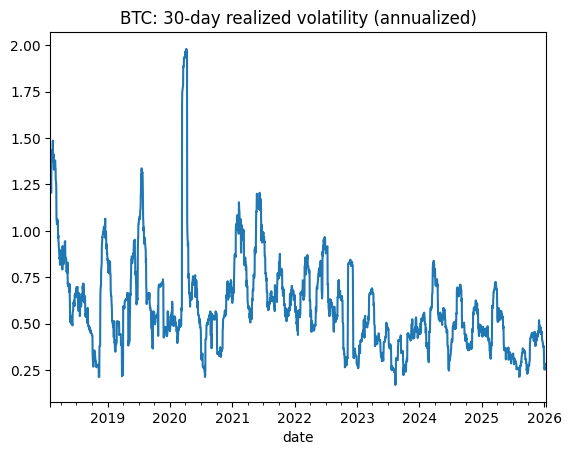

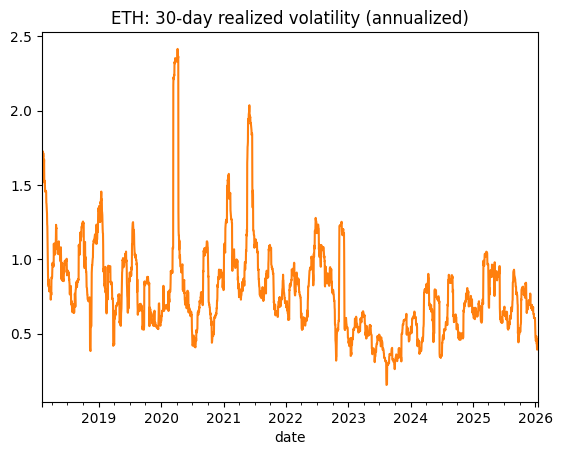

In [14]:
plt.figure()
btc_df["realized_vol"].plot(color="tab:blue")
plt.title("BTC: 30-day realized volatility (annualized)")
plt.show()

plt.figure()
eth_df["realized_vol"].plot(color="tab:orange")
plt.title("ETH: 30-day realized volatility (annualized)")
plt.show()


BTC and ETH realized volatility exhibit strong clustering, with extended periods of elevated volatility followed by quieter regimes. This behavior motivates regime-based analysis, as volatility is clearly time-varying rather than random. The similarity in structure but difference in magnitude suggests common market dynamics with asset-specific risk intensity, an important note when moving forward. 

In [20]:
btc_summary = regime_summary(btc_df)
eth_summary = regime_summary(eth_df)

print("BTC:")
display(btc_summary)

print("ETH:")
display(eth_summary)

BTC:


,N,MeanRet,StdRet,MeanAbsRet,MeanRet2,MeanRealizedVol,Ret_q05,Ret_q95
vol_regime,,,,,,,,
HighVol,959,0.000341,0.046334,0.032376,0.002145,0.870336,-0.068987,0.074675
LowVol,959,0.001631,0.019407,0.013529,0.000379,0.363527,-0.026846,0.033999
MidVol,989,0.000369,0.029853,0.021007,0.000890,0.549690,-0.048341,0.046922


ETH:


,N,MeanRet,StdRet,MeanAbsRet,MeanRet2,MeanRealizedVol,Ret_q05,Ret_q95
vol_regime,,,,,,,,
HighVol,959,-0.001240,0.058745,0.040327,0.003449,1.124635,-0.091380,0.091188
LowVol,959,0.002092,0.027593,0.020068,0.000765,0.503420,-0.042198,0.048428
MidVol,989,0.000310,0.041403,0.029863,0.001713,0.745796,-0.067566,0.066424


Summary statistics by volatility regime reveal that both BTC and ETH exhibit strong regime dependence in risk characteristics. High-volatility regimes are associated with substantially larger return dispersion and heavier tails, while mean returns remain close to zero across all regimes. This indicates that volatility regimes primarily govern risk rather than expected return. ETH consistently displays higher realized volatility and more extreme tail behavior than BTC, particularly during high-volatility periods. These findings motivate volatility-aware risk management approaches rather than short-horizon return forecasting.

In [21]:
btc_T = regime_transition_matrix(btc_df["vol_regime"], normalize=True)
eth_T = regime_transition_matrix(eth_df["vol_regime"], normalize=True)

btc_T, eth_T

(vol_regime   HighVol    LowVol    MidVol
 vol_regime                              
 HighVol     0.949948  0.001043  0.049009
 LowVol      0.001044  0.953027  0.045929
 MidVol      0.046512  0.045501  0.907988,
 vol_regime   HighVol    LowVol    MidVol
 vol_regime                              
 HighVol     0.952033  0.000000  0.047967
 LowVol      0.000000  0.953027  0.046973
 MidVol      0.045501  0.046512  0.907988)

The volatility regime transition matrices indicate strong persistence across regimes. Once BTC or ETH enters a high-volatility regime, it remains there with approximately 95% day-to-day probability, with similarly high persistence observed in low-volatility regimes. Transitions between regimes occur infrequently and are asymmetric, suggesting that volatility dynamics are path-dependent rather than memoryless.

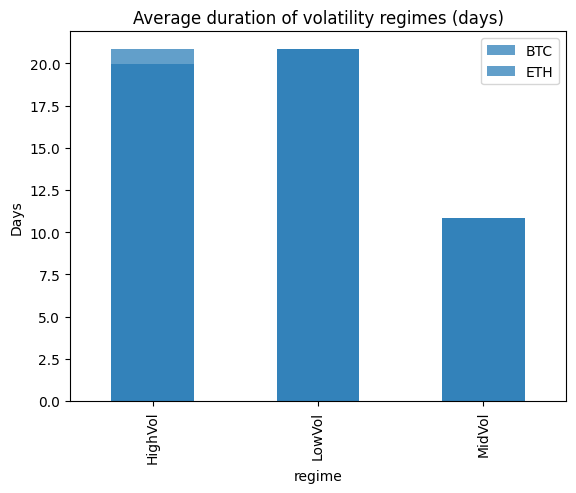

In [26]:
btc_spans = regime_spans(btc_df)
eth_spans = regime_spans(eth_df)

btc_durations = btc_spans.groupby("regime")["n_days"].mean()
eth_durations = eth_spans.groupby("regime")["n_days"].mean()

plt.figure()
btc_durations.plot(kind="bar", alpha=0.7, label="BTC")
eth_durations.plot(kind="bar", alpha=0.7, label="ETH")
plt.title("Average duration of volatility regimes (days)")
plt.ylabel("Days")
plt.legend()
plt.show()


Both Bitcoin and Ethereum exhibit strong persistence in volatility regimes, with low- and high-volatility states lasting significantly longer than mid-volatility periods. This indicates that volatility in crypto markets tends to cluster into sustained regimes rather than fluctuating randomly day-to-day. The consistency across assets suggests common underlying volatility dynamics, supporting the use of regime-based risk frameworks rather than short-horizon return forecasting.

This analysis examined two complementary aspects of crypto market dynamics: short-horizon return predictability and volatility regime structure. ARIMA models applied to daily log returns for BTC and ETH show limited out-of-sample predictive power in mean returns, consistent with weak-form market efficiency at the daily horizon. In contrast, realized volatility exhibits clear regime structure and persistence across time.